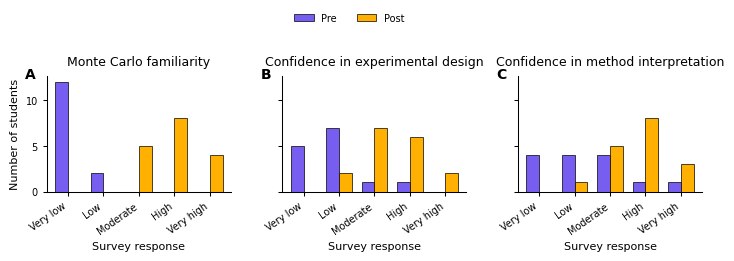

In [2]:
# Figure 1: Pre/post survey histograms for Monte Carlo kinetics activity
# Author: J. Mills / ChatGPT-assisted draft
# Purpose: Generate publication-quality SVG/PDF/PNG figure with three histograms:
#   1. Monte Carlo familiarity
#   2. Confidence in experimental design
#   3. Confidence in method interpretation

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

output_dir = Path("figure_output")
output_dir.mkdir(exist_ok=True)

# IBM colorblind-safe palette provided by Jeff
IBM = {
    "gold":   (255/255, 176/255,   0/255),
    "orange": (254/255,  97/255,   0/255),
    "magenta":(220/255,  38/255, 127/255),
    "purple": (120/255,  94/255, 240/255),
    "blue":   (100/255, 143/255, 255/255),
    "black":  (0/255,     0/255,   0/255),
}

# Choose colors for pre/post
PRE_COLOR = IBM["purple"]
POST_COLOR = IBM["gold"]
EDGE_COLOR = IBM["black"]

# Publication font settings
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "svg.fonttype": "none",        # keeps text editable in Illustrator
    "pdf.fonttype": 42,            # editable TrueType fonts in PDF
    "ps.fonttype": 42,
    "axes.linewidth": 0.75,
})

# ------------------------------------------------------------
# OPTION A: ENTER RAW RESPONSES
# ------------------------------------------------------------
# Replace these example values with your actual pre/post survey data.
# Assumes Likert scale:
#   1 = Very low / Not familiar
#   2 = Low
#   3 = Moderate
#   4 = High
#   5 = Very high

raw_data = {
    "Monte Carlo familiarity": {
        "pre":  [1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1],
        "post": [5, 5, 4, 4, 4, 3, 4, 4, 5, 3, 4, 5, 4, 3, 3, 4, 3],
    },
    "Confidence in experimental design": {
        "pre":  [3, 4, 1, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 2],
        "post": [5, 4, 3, 3, 4, 3, 4, 4, 5, 3, 4, 4, 3, 2, 2, 3, 3],
    },
    "Confidence in method interpretation": {
        "pre":  [2, 5, 1, 1, 1, 2, 3, 3, 2, 2, 3, 3, 4, 1],
        "post": [5, 5, 3, 3, 4, 3, 4, 4, 5, 3, 4, 4, 4, 2, 3, 4, 4],
    },
}

# ------------------------------------------------------------
# OPTION B: USE PRE-COUNTED VALUES INSTEAD
# ------------------------------------------------------------
# If you prefer to enter counts directly, set USE_COUNTS = True
# and edit the count_data dictionary.
#
# Example: "pre":  [number of 1s, number of 2s, number of 3s, number of 4s, number of 5s]

USE_COUNTS = False

count_data = {
    "Monte Carlo familiarity": {
        "pre":  [6, 5, 4, 0, 0],
        "post": [0, 1, 5, 7, 2],
    },
    "Confidence in experimental design": {
        "pre":  [0, 7, 7, 1, 0],
        "post": [0, 0, 3, 9, 3],
    },
    "Confidence in method interpretation": {
        "pre":  [0, 7, 7, 1, 0],
        "post": [0, 0, 2, 10, 3],
    },
}

# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

likert_values = np.array([1, 2, 3, 4, 5])
likert_labels = [
    "Very low",
    "Low",
    "Moderate",
    "High",
    "Very high"
]

def responses_to_counts(responses):
    """Convert raw Likert responses into counts for values 1–5."""
    responses = np.asarray(responses)
    return np.array([(responses == value).sum() for value in likert_values])

def get_counts(dataset, title):
    """Return pre/post counts for a given survey item."""
    if USE_COUNTS:
        pre_counts = np.asarray(count_data[title]["pre"])
        post_counts = np.asarray(count_data[title]["post"])
    else:
        pre_counts = responses_to_counts(raw_data[title]["pre"])
        post_counts = responses_to_counts(raw_data[title]["post"])
    return pre_counts, post_counts

# ------------------------------------------------------------
# MAKE FIGURE
# ------------------------------------------------------------

fig_width = 7.2     # inches; good for two-column-ish JCE layout
fig_height = 2.4

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(fig_width, fig_height),
    sharey=True,
    constrained_layout=False
)

bar_width = 0.36
x = np.arange(len(likert_values))

panel_labels = ["A", "B", "C"]

for ax, title, panel_label in zip(axes, raw_data.keys(), panel_labels):

    pre_counts, post_counts = get_counts(raw_data, title)

    ax.bar(
        x - bar_width/2,
        pre_counts,
        width=bar_width,
        color=PRE_COLOR,
        edgecolor=EDGE_COLOR,
        linewidth=0.5,
        label="Pre"
    )

    ax.bar(
        x + bar_width/2,
        post_counts,
        width=bar_width,
        color=POST_COLOR,
        edgecolor=EDGE_COLOR,
        linewidth=0.5,
        label="Post"
    )

    # Panel label
    ax.text(
        -0.12, 1.08,
        panel_label,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
        ha="left"
    )

    ax.set_title(title, pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(likert_labels, rotation=35, ha="right")
    ax.set_xlabel("Survey response")

    # Clean publication style
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3, width=0.75)

axes[0].set_ylabel("Number of students")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.08)
)

# Adjust spacing manually for Illustrator-friendly layout
fig.subplots_adjust(
    left=0.08,
    right=0.99,
    bottom=0.30,
    top=0.78,
    wspace=0.28
)

# ------------------------------------------------------------
# EXPORT
# ------------------------------------------------------------

fig.savefig(output_dir / "figure1_survey_histograms.svg", bbox_inches="tight")
fig.savefig(output_dir / "figure1_survey_histograms.pdf", bbox_inches="tight")
fig.savefig(output_dir / "figure1_survey_histograms.png", dpi=600, bbox_inches="tight")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Print all font names matplotlib can currently see
fonts = sorted(set(f.name for f in fm.fontManager.ttflist))

for font in fonts:
    print(font)

DejaVu Sans
DejaVu Sans Display
DejaVu Sans Mono
DejaVu Serif
DejaVu Serif Display
Humor Sans
Liberation Mono
Liberation Sans
Liberation Sans Narrow
Liberation Serif
STIXGeneral
STIXNonUnicode
STIXSizeFiveSym
STIXSizeFourSym
STIXSizeOneSym
STIXSizeThreeSym
STIXSizeTwoSym
cmb10
cmex10
cmmi10
cmr10
cmss10
cmsy10
cmtt10
